<a href="https://colab.research.google.com/github/ROHAN-BIT001/logistic-regression/blob/main/Diabetes_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Project: Diabetes Prediction
**Student:** Rohan Jha  |  **Date:** 04 Oct 2026

**Objective:** Predict `Outcome` (0 = No diabetes, 1 = Diabetes) using the Pima Indians Diabetes Database from Kaggle (`diabetes.csv`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Load and inspect data

In [ ]:
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)

print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Replace invalid values
In this dataset a value of 0 is not possible for Glucose, BloodPressure, SkinThickness, Insulin and BMI, so zeros mean the value was not recorded.

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


There are no zeros in this file, but Insulin and SkinThickness have the same value repeated many times. Checking by Outcome:

In [ ]:
print(df.groupby('Outcome')['Insulin'].agg(lambda s: s.value_counts().index[0]))
print(df.groupby('Outcome')['SkinThickness'].agg(lambda s: s.value_counts().index[0]))
print(df['Insulin'].value_counts().head(2))
print(df['SkinThickness'].value_counts().head(2))

Outcome
0    102.5
1    169.5
Name: Insulin, dtype: float64
Outcome
0    27
1    32
Name: SkinThickness, dtype: int64
Insulin
102.5    236
169.5    138
Name: count, dtype: int64
SkinThickness
27    162
32    119
Name: count, dtype: int64


These repeated values (Insulin 102.5 and 169.5, SkinThickness 27 and 32) are different for each Outcome, so they were filled in using the answer and are not real readings. I treat them as missing again and fill them later with the median from the training data.

In [ ]:
df['Insulin'] = df['Insulin'].replace([102.5, 169.5], np.nan)
df['SkinThickness'] = df['SkinThickness'].replace([27, 32], np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               281
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## Exploratory Data Analysis

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


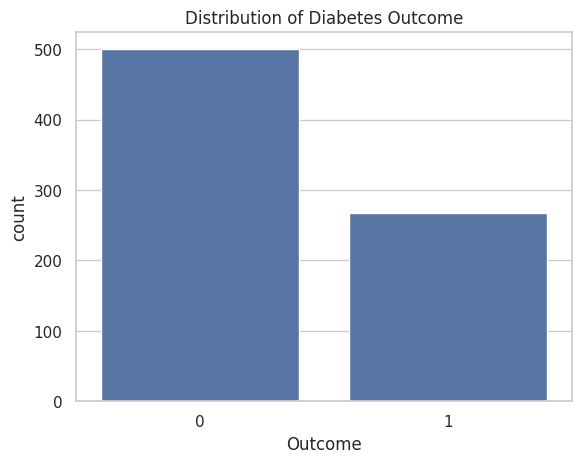

In [ ]:
# Univariate analysis
print(df['Outcome'].value_counts(normalize=True) * 100)
sns.countplot(data=df, x='Outcome')
plt.title('Distribution of Diabetes Outcome')
plt.show()

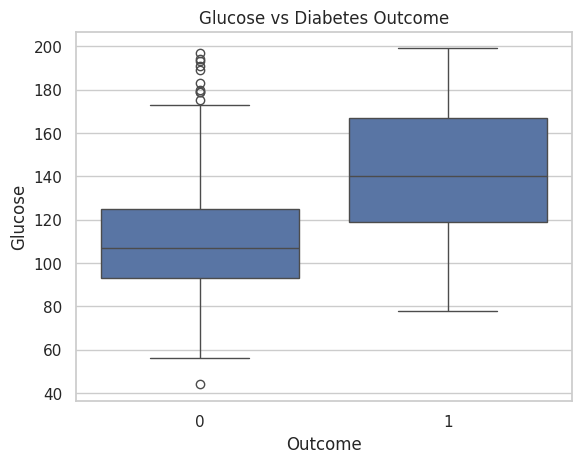

In [ ]:
# Bivariate analysis
sns.boxplot(data=df, x='Outcome', y='Glucose')
plt.title('Glucose vs Diabetes Outcome')
plt.show()

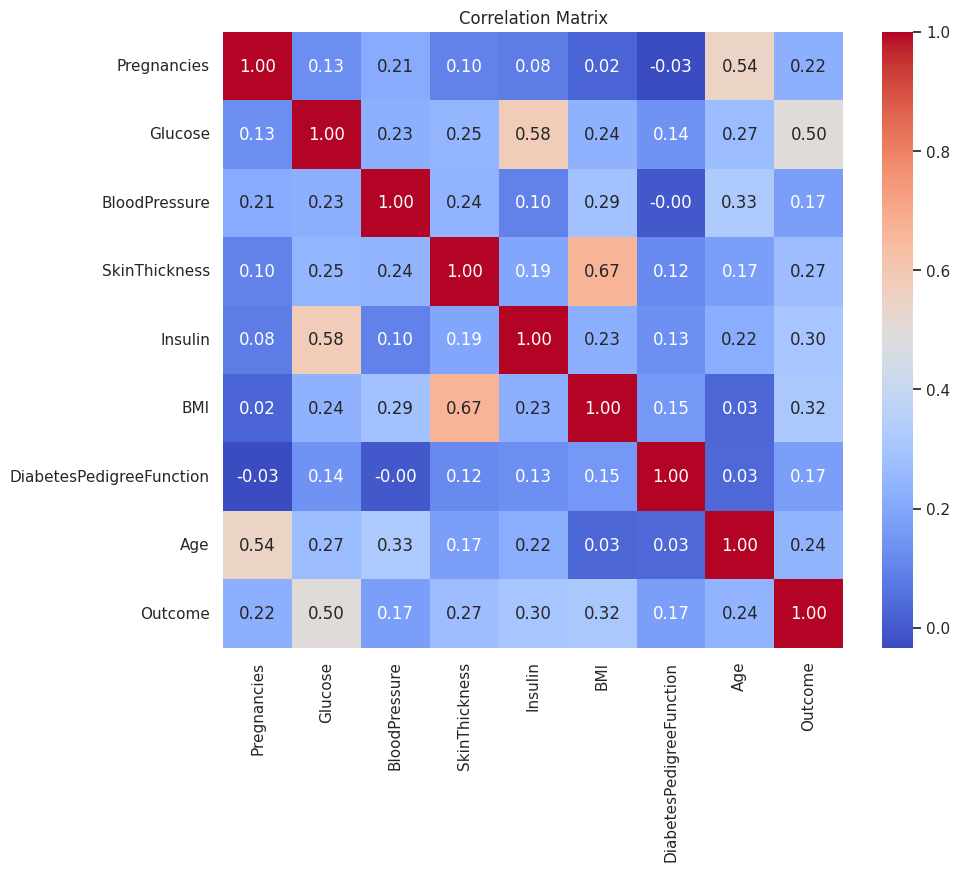

In [ ]:
# Multivariate analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

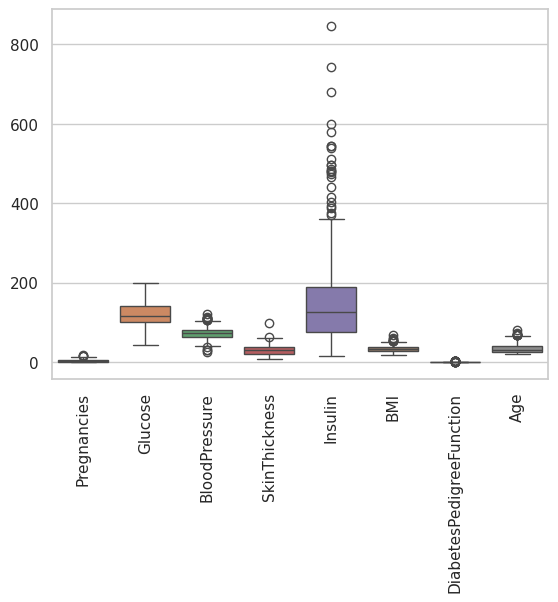

In [ ]:
# Outlier detection
sns.boxplot(data=df.drop('Outcome', axis=1))
plt.xticks(rotation=90)
plt.show()

## Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


## Model: median imputation + scaling + balanced Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("accuracy:", round(accuracy, 3))
print("precision:", round(precision, 3))
print("recall:", round(recall, 3))
print("f1 score:", round(f1, 3))
print("roc auc:", round(roc_auc, 3))
print("classification report:\n", classification_report(y_test, y_pred))

accuracy: 0.721
precision: 0.587
recall: 0.685
f1 score: 0.632
roc auc: 0.811
classification report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



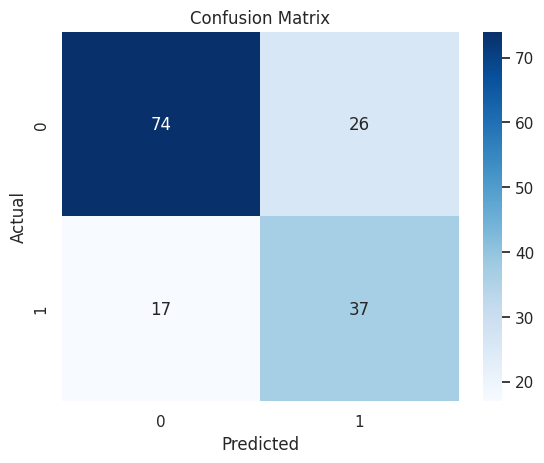

TN = 74 FP = 26 FN = 17 TP = 37


In [ ]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('TN =', tn, 'FP =', fp, 'FN =', fn, 'TP =', tp)

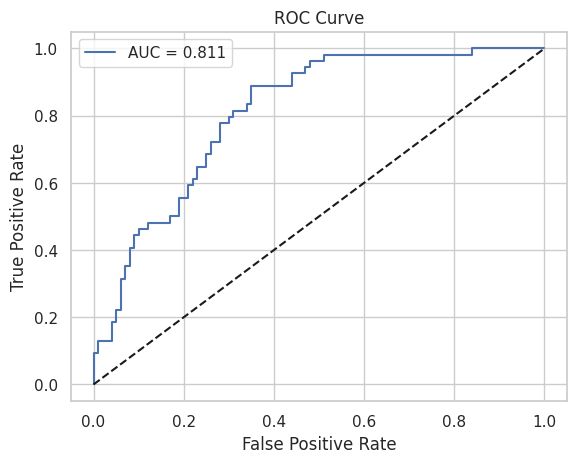

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Interpret coefficients

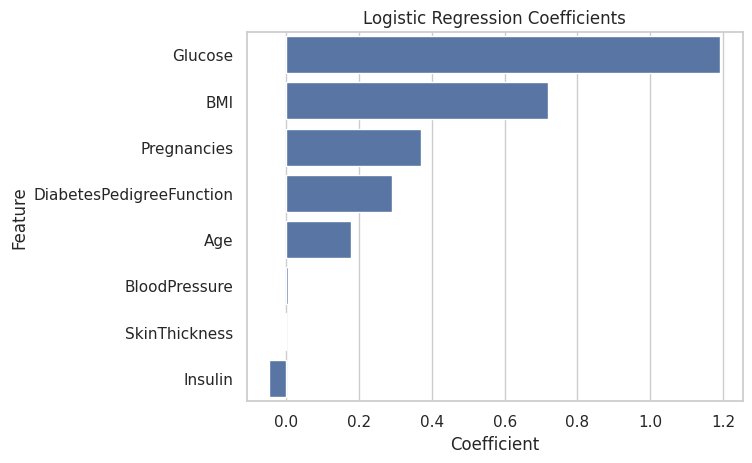

,Feature,Coefficient
0,Glucose,1.192036
1,BMI,0.718802
2,Pregnancies,0.368890
3,DiabetesPedigreeFunction,0.290189
4,Age,0.179014
5,BloodPressure,0.005347
6,SkinThickness,-0.004093
7,Insulin,-0.046477


In [ ]:
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.named_steps['lr'].coef_[0]})
coef = coef.sort_values('Coefficient', ascending=False).reset_index(drop=True)
sns.barplot(data=coef, x='Coefficient', y='Feature')
plt.title('Logistic Regression Coefficients')
plt.show()
coef

## Conclusion

In this project I built a Logistic Regression model to predict diabetes from the Pima Indians dataset. After the train-test split the model reached an accuracy of 0.721 and a ROC-AUC of 0.811. It found 37 out of 54 diabetic patients (recall 0.685) but also gave 26 false alarms, so precision is only 0.587. Glucose and BMI have the highest positive coefficients, which means they affect the prediction of diabetes the most.

Recall matters more here because a false negative means a diabetic patient is missed, while a false positive only needs one more test. While cleaning the data I saw that Insulin and SkinThickness had filled-in values that depended on the Outcome, so I treated them as missing and imputed them with the training median. The dataset is small and comes from one population, so this model is only for learning and not for real medical diagnosis.